So, in this case we update the weight of the equation for both the scenarios.

1. When random point is not classified correctly ( pull line towards the point )
2. When random point is classified correctly. ( push line away from the point )


Now, in this there are different scenarios becasue we want to centrilize the line and the line should properly drawn. So for that.

A. pull line towards the point

1. When random point is close to line and not classfied properly, the line will be pulled with low magnitude.
2. When random point is away from line and not classfied properly, the line will be pulled with high magnitude.


B. push line away from the point

1. When random point is close to line and classfied properly, the line will be pushed with high magnitude/distance.
2. When random point is away from line and classfied properly, the line will be pushed with low magnitud/distace.

#

This is the equation we use for perceptron tric,

$
w_n = w_0 + \eta (y_i - \hat{y}_i) x_i
$

We need to make changes in this equation.

Key Points:
1. from this above equation, we have yi which i outputFeature.
2. Y_hat which is our model prediction and we are predicting that using the line equation and function which is step function.
3. Step function gives as output as either 0 or 1
4. And as per our requirement of pushing and pulling we dont want output as 0 and 1. 
5. That is the reason we are using sigmoid activation function.



### Sigmoid Activation Function
$
\sigma(z) = \frac{1}{1 + e^{-z}}
$

- Derivative of Sigmoid function is always, 
$
\sigma(z) = \sigma(z). (1 - \sigma(z))
$


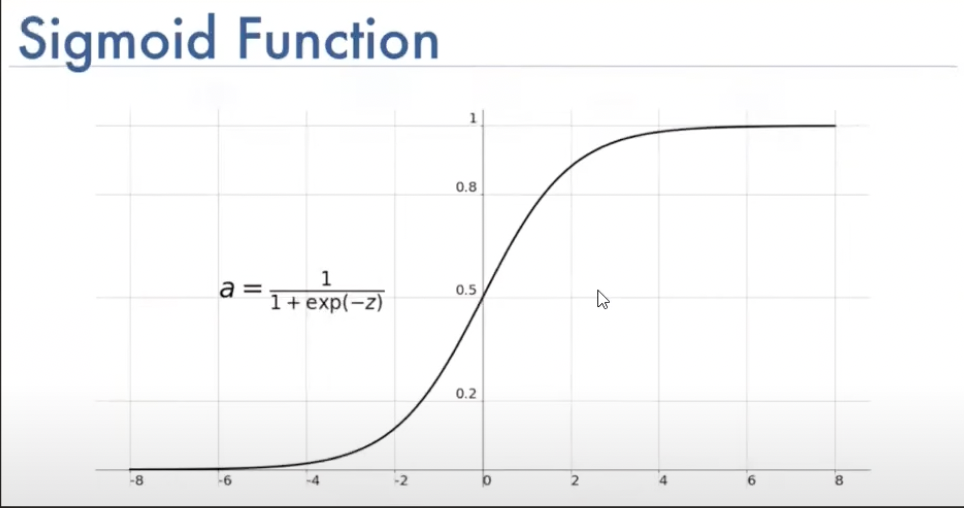

In [16]:
from sklearn.datasets import make_classification
import numpy as np
import matplotlib.pyplot as plt
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [17]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [18]:
def perceptron(X,y):
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    learning_rate = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step_fn(np.dot(X[j],weights))
        weights = weights + learning_rate*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [19]:
def step_fn(z):
    return 1 if z>0 else 0

In [20]:
intercept_,coef_ = perceptron(X,y)
print(coef_)

print(intercept_)

[1.08682872 0.52024363]
1.2000000000000002


In [21]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

(-3.0, 2.0)

In [22]:
def perceptron(X,y):
    
    m = []
    b = []
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step_fn(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))
        
    return m,b

In [23]:
m,b = perceptron(X,y)

In [24]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(9,5))

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m[0] +b[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m[0] +b[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m[i] + b[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
anim.save('perceptron_anim.mp4')

<IPython.core.display.Javascript object>

In [25]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression()
lor.fit(X,y)

LogisticRegression()

In [26]:
m = -(lor.coef_[0][0]/lor.coef_[0][1])
b = -(lor.intercept_/lor.coef_[0][1])

x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input + b

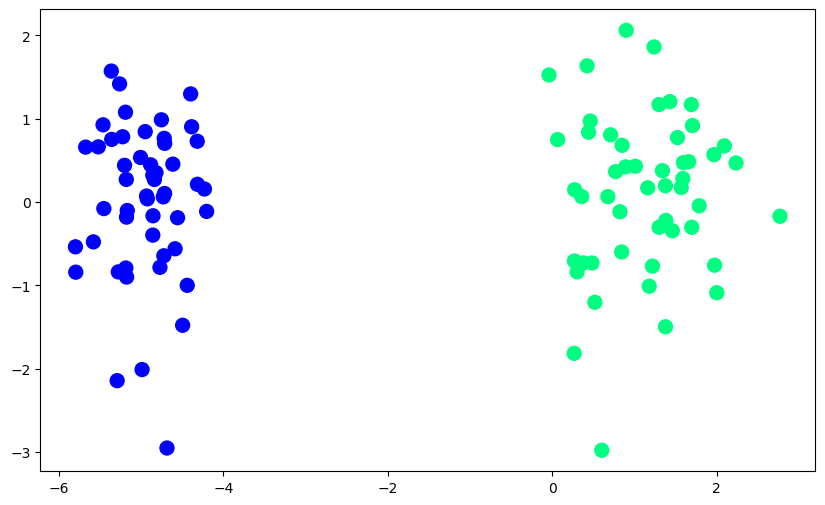

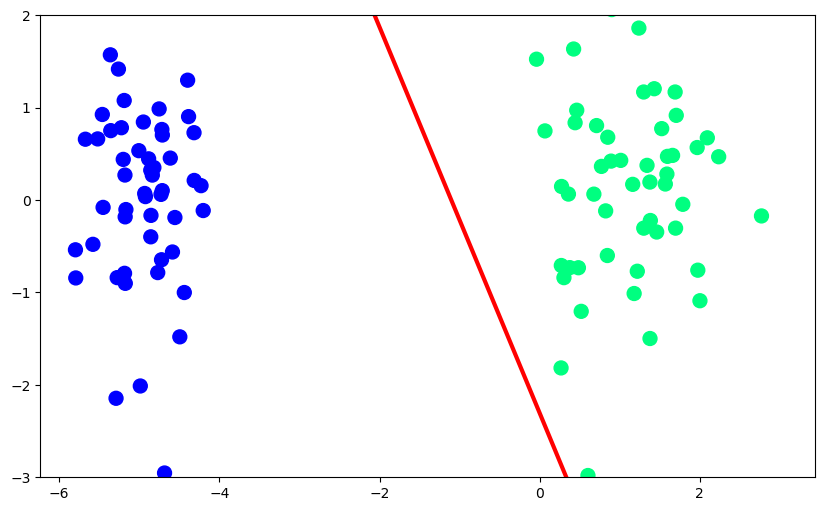

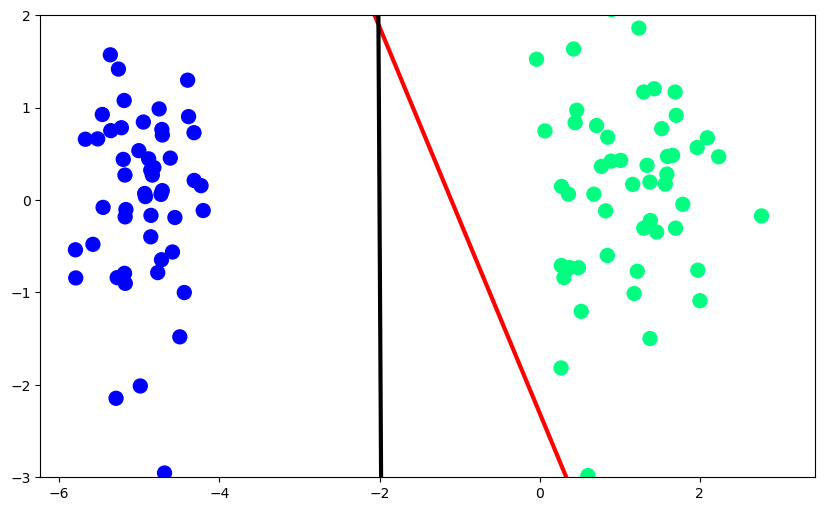

In [27]:
%matplotlib inline
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show();

In [28]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = sigmoid(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [29]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [30]:
intercept_,coef_ = perceptron(X,y)

In [31]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

x_input2 = np.linspace(-3,3,100)
y_input2 = m*x_input + b

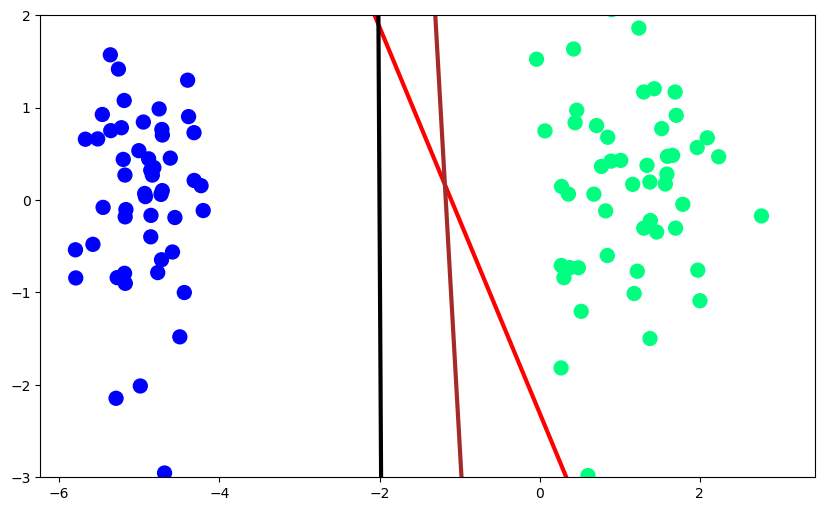

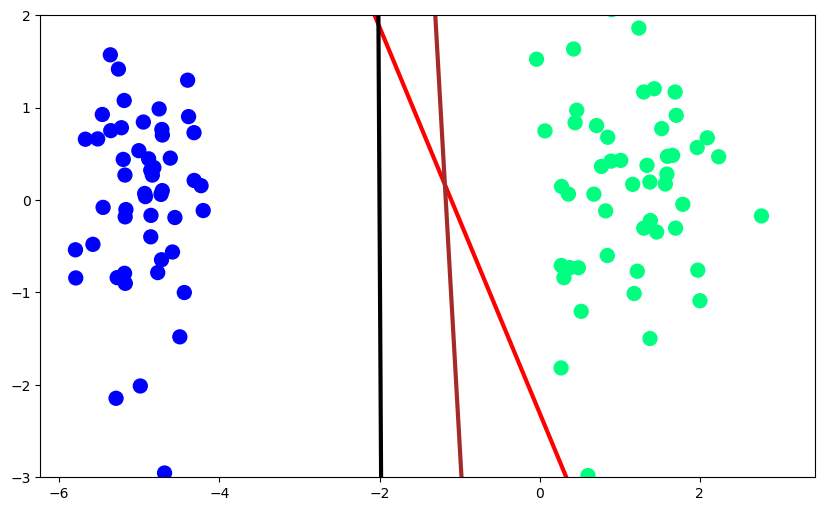

In [33]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='black',linewidth=3)
plt.plot(x_input2,y_input2,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)
plt.show();

-  almost there like logistic regression of sklearn when we use sigmoid function. 
- But still there is area of improvement as we are not getting the exact similar line.


- To avoid this and get proper solution we work with loss function / error function. 
- We use technique called Maximum likelywood, cross entropy (minimum cross entropy)
- We will use log-loss error function also called binary cross entropy function. and there is no such closed form solution for this function. and so that we have to apply gradient descent in this case.



First form:
$
L = \sum_{i=1}^{n} \left[ -y_i \log(\hat{y}_i) - (1 - y_i) \log(1 - \hat{y}_i) \right]
$

Average form (normalized by \( n \)):
$
L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]
$